In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:



def generate_patch(img, length, gray=False, start=None):
    h, w = img.shape[:2]

    if length > h or length > w:
        raise ValueError("Patch size larger than image dimensions")

    if start is None:
        x = np.random.randint(0, h - length + 1)
        y = np.random.randint(0, w - length + 1)
    else:
        x, y = start
        if x < 0 or y < 0 or x + length > h or y + length > w:
            raise ValueError("Invalid start location")

    patch = img[x:x + length, y:y + length]

    if gray:
        if len(patch.shape) == 3 and patch.shape[2] >= 3:
            patch = (0.299 * patch[:, :, 0] +
                     0.587 * patch[:, :, 1] +
                     0.114 * patch[:, :, 2]).astype(img.dtype)
        elif len(patch.shape) == 3 and patch.shape[2] == 1:
            patch = patch.squeeze()

    return patch, [x,y]

In [3]:


def load_image(path):
    """
    Takes image path and returns image as numpy matrix
    """
    img = Image.open(path)
    return np.array(img)


def plot_image(img_arr):
    """
    Takes image matrix and plots depending on grayscale or RGB
    """
    if len(img_arr.shape) == 2:  # Grayscale
        plt.imshow(img_arr, cmap="viridis")
        plt.title("Grayscale Image")

    elif len(img_arr.shape) == 3:
        if img_arr.shape[2] == 1:  # Grayscale with single channel
            plt.imshow(img_arr.squeeze(), cmap="viridis")
            plt.title("Grayscale Image")
        else:  # RGB or more channels
            plt.imshow(img_arr)
            plt.title("RGB Image")

    else:
        raise ValueError("Unsupported image format")

    plt.axis("off")
    plt.show()



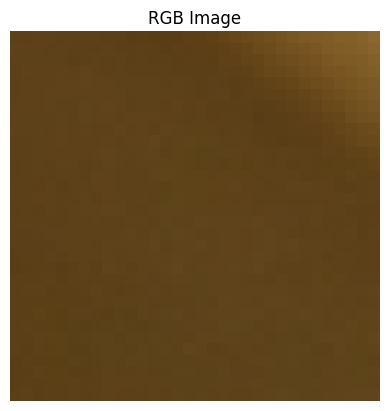

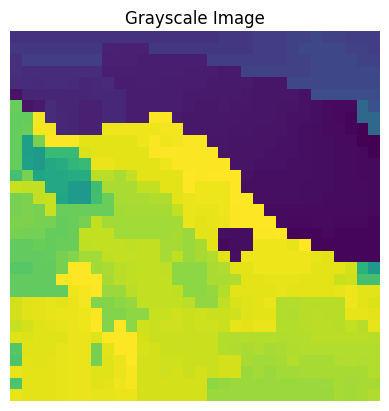

In [12]:

# Example usage
img = load_image("/mnt/Personal/Projects/Autofocus/test_images/image/table.jpg")
img_patch,point = generate_patch(img,32)
plot_image(img_patch)
depth = load_image("/mnt/Personal/Projects/Autofocus/test_images/depth/table.png")
depth_patch,point = generate_patch(depth,32,start=point)
plot_image(depth_patch)